# E-Scooter IMU Dataset — Exploration
First look at the two field recordings and comparison of candidate methods for turning acceleration into a vibration signal.
Exploratory work: the final method is in `escooter-vibration-validation`. Outputs: results/.

In [1]:
# 0. Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# 1. Input files

# folder on the local machine that contains the CSV files
data_dir = Path.home() / "Desktop" / "scooter_pro"

files = {
    "Sidewalk": "imu_accel_sidewalk_cafe.csv",
    "Asphalt": "imu_accel_cafe_asphalt.csv",
}

# figures and CSV outputs are saved in results/ next to this notebook
# (VS Code sets __vsc_ipynb_file__ to the notebook path; otherwise the current folder is used)
notebook_dir = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
out_dir = notebook_dir / "results"
out_dir.mkdir(exist_ok = True)
print(f"results folder: {out_dir}")

datasets = {name: pd.read_csv(data_dir / path) for name, path in files.items()}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df['time_sec'].iloc[-1]:.1f} seconds")

results folder: /Users/sarvin/Desktop/scooter_pro/escooter-dataset-exploration/results
Sidewalk: 110881 rows, 549.4 seconds
Asphalt: 119128 rows, 593.1 seconds


In [3]:
# 2. First rows and summary statistics of each recording

for name, df in datasets.items():
    print(name)
    display(df.head())
    display(df[["ax", "ay", "az"]].describe())

Sidewalk


,timestamp_ns,time_sec,ax,ay,az
0,1781986317104198040,0.004455,-3.259163,-7.669312,-5.064337
1,1781986317109059143,0.009316,-3.426140,-7.766805,-4.899684
2,1781986317114075037,0.014332,-3.170181,-7.679608,-5.079830
3,1781986317118846010,0.019103,-3.249598,-7.669084,-4.975357
4,1781986317124320586,0.024578,-3.319280,-7.648729,-4.870912


,ax,ay,az
count,110881.000000,110881.000000,110881.000000
mean,-0.106802,-6.585115,-5.740069
std,2.556302,6.094622,6.231385
min,-39.135883,-39.800144,-42.145992
25%,-0.753728,-8.531447,-6.965973
50%,0.114994,-8.491733,-4.727767
75%,0.461131,-4.972659,-4.647573
max,39.511520,39.471390,41.519691


Asphalt


,timestamp_ns,time_sec,ax,ay,az
0,1781987679946918553,0.002082,-0.834377,-8.115489,-5.572670
1,1781987679951562437,0.006725,-1.638165,-8.779983,-4.494154
2,1781987679956457178,0.011620,-1.998028,-10.089082,-3.791625
3,1781987679961601369,0.016764,-3.247326,-11.159014,-3.589853
4,1781987679966706262,0.021869,-0.312387,-10.523106,-4.587456


,ax,ay,az
count,119128.000000,119128.000000,119128.000000
mean,1.486173,-8.812750,-3.624480
std,2.404167,3.884518,4.392659
min,-39.958481,-39.881329,-41.862724
25%,1.538382,-8.695314,-3.951925
50%,2.038296,-8.675587,-3.940836
75%,2.048487,-8.665635,-3.896585
max,40.043579,39.434544,39.909298


In [4]:
# 3. Sampling rate and the largest timing gaps

def check_gaps(df, name, n = 10):
    dt = df["time_sec"].diff()
    median_dt = dt.median()
    print(f"{name}: median dt = {median_dt:.5f}s (~{1/median_dt:.1f} Hz), duration = {df['time_sec'].iloc[-1]:.1f}s")
    print(f"{name}: top {n} largest gaps:")
    print(dt.sort_values(ascending = False).head(n))
    print()

for name, df in datasets.items():
    check_gaps(df, name)

Sidewalk: median dt = 0.00498s (~200.7 Hz), duration = 549.4s
Sidewalk: top 10 largest gaps:
62044     0.376701
19671     0.275159
34306     0.199142
94379     0.172107
101401    0.144645
65905     0.111289
81786     0.071280
80309     0.070562
73019     0.060524
24668     0.045926
Name: time_sec, dtype: float64

Asphalt: median dt = 0.00497s (~201.0 Hz), duration = 593.1s
Asphalt: top 10 largest gaps:
30778    1.315559
28883    0.783361
19323    0.547727
61619    0.360162
73119    0.336959
51890    0.328709
26978    0.193152
76836    0.186422
97497    0.143240
10144    0.142846
Name: time_sec, dtype: float64



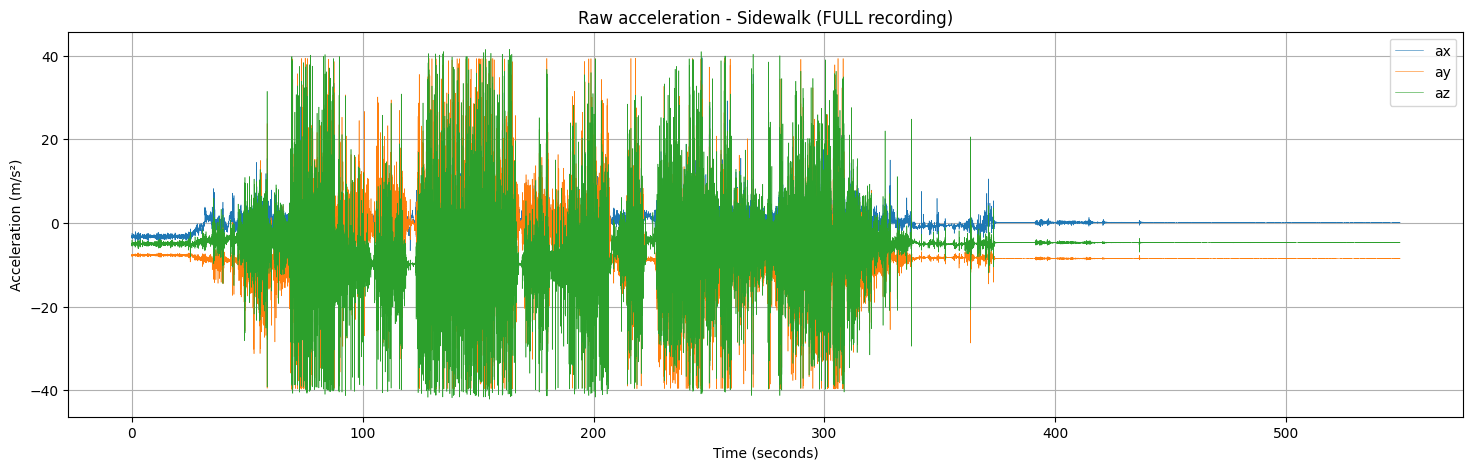

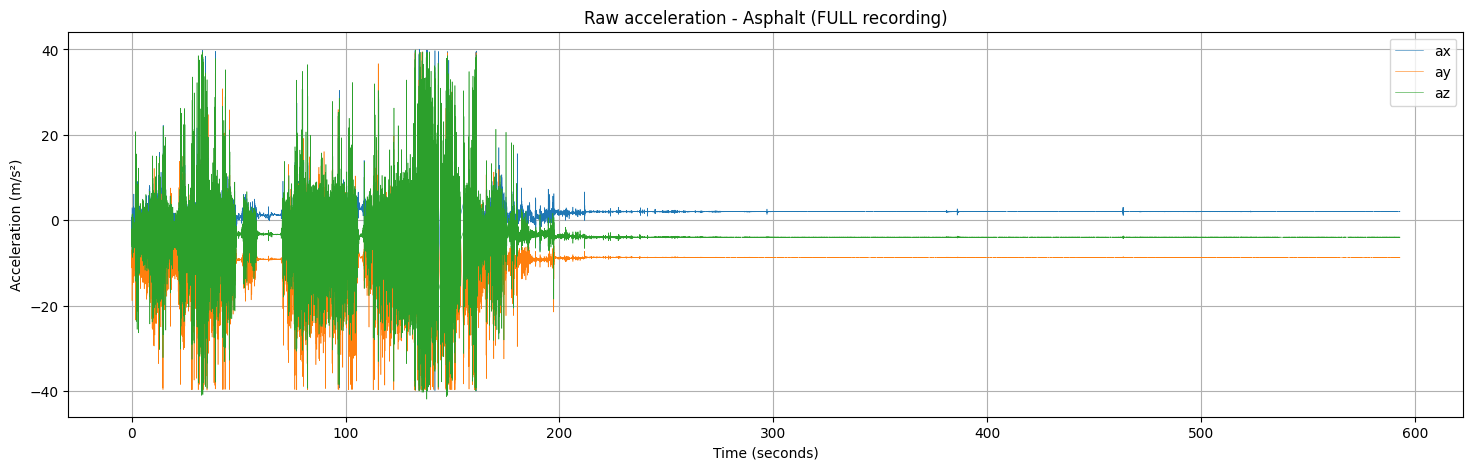

In [5]:
# 4. Raw acceleration: full recordings

for name, df in datasets.items():
    plt.figure(figsize = (18, 5))
    plt.plot(df["time_sec"], df["ax"], label = "ax", linewidth = 0.4)
    plt.plot(df["time_sec"], df["ay"], label = "ay", linewidth = 0.4)
    plt.plot(df["time_sec"], df["az"], label = "az", linewidth = 0.4)
    plt.title(f"Raw acceleration - {name} (FULL recording)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Acceleration (m/s²)")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / f"raw_full_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

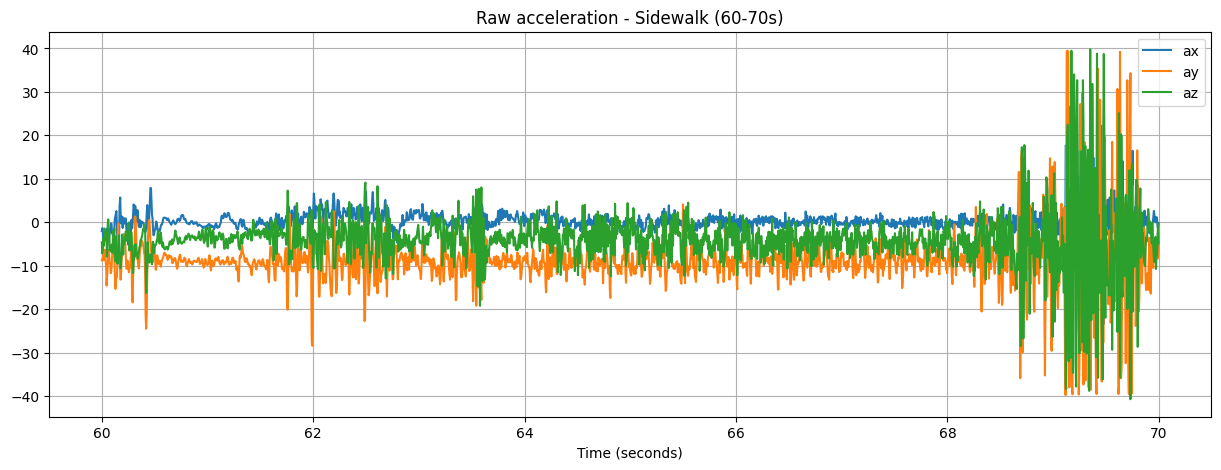

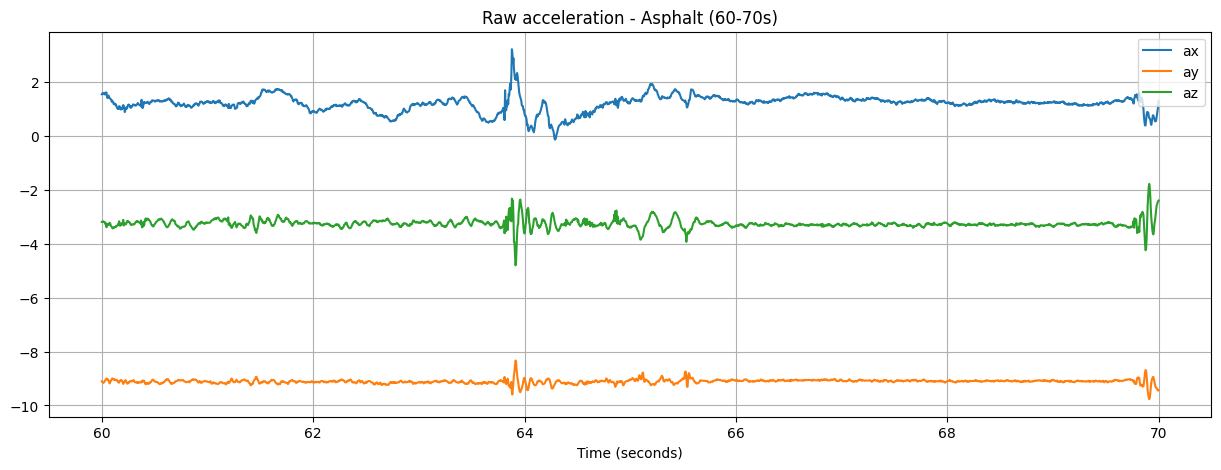

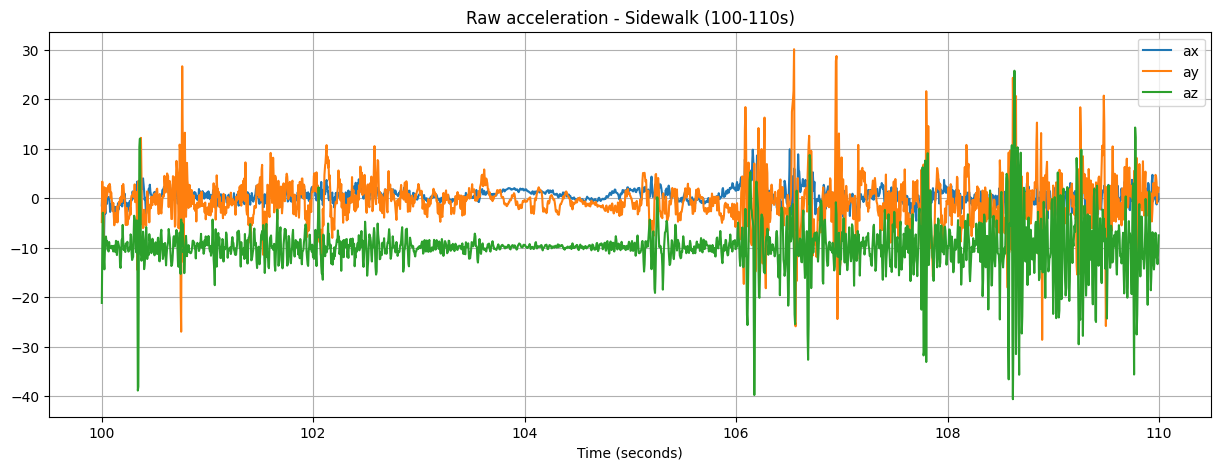

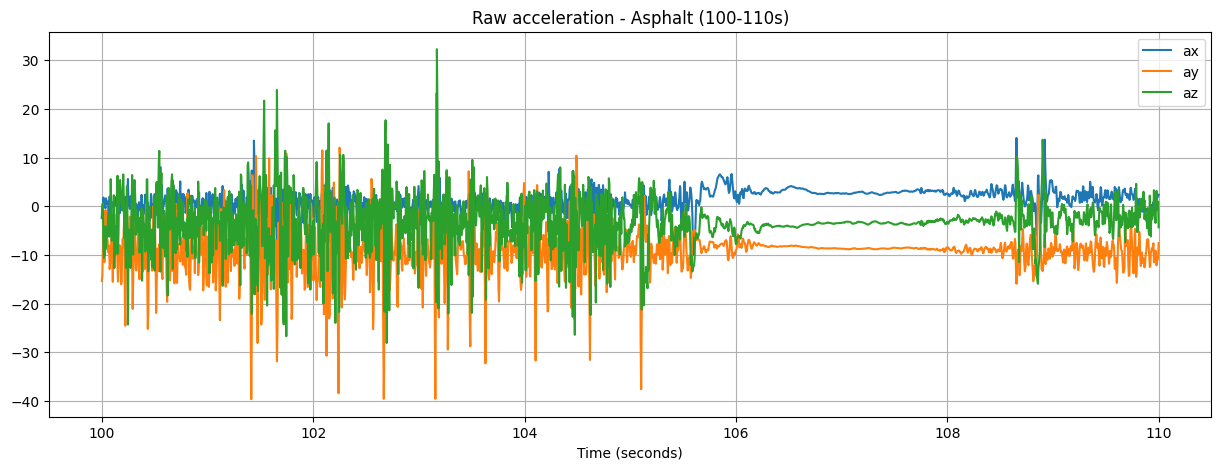

In [6]:
# 5. Raw acceleration: 10-s zooms

zoom_windows = [(60, 70), (100, 110)]

for start, end in zoom_windows:
    for name, df in datasets.items():
        zoom = df[(df["time_sec"] >= start) & (df["time_sec"] <= end)]
        plt.figure(figsize = (15, 5))
        plt.plot(zoom["time_sec"], zoom["ax"], label = "ax")
        plt.plot(zoom["time_sec"], zoom["ay"], label = "ay")
        plt.plot(zoom["time_sec"], zoom["az"], label = "az")
        plt.title(f"Raw acceleration - {name} ({start}-{end}s)")
        plt.xlabel("Time (seconds)")
        plt.legend()
        plt.grid(True)
        plt.savefig(out_dir / f"raw_zoom_{start}_{end}s_{name}.png", dpi = 200, bbox_inches = "tight")
        plt.show()

In [7]:
# 6. Two candidate ways to remove gravity, and three candidate vibration magnitudes

# gravity removal A: subtract the mean of the whole recording
def remove_mean(df):
    df = df.copy()
    for axis in ("ax", "ay", "az"):
        df[f"{axis}_meanrm"] = df[axis] - df[axis].mean()
    return df

# gravity removal B: subtract a first-order low-pass estimate of gravity
def first_order_lowpass(signal, dt, cutoff_hz = 0.5):
    rc = 1.0 / (2 * np.pi * cutoff_hz)
    alpha = rc / (rc + dt)
    y = np.empty_like(signal, dtype = float)
    y[0] = signal[0]
    for i in range(1, len(signal)):
        y[i] = alpha * y[i - 1] + (1 - alpha) * signal[i]
    return y

def remove_gravity_lowpass(df, cutoff_hz = 0.5):
    df = df.copy()
    dt = df["time_sec"].diff().median()
    for axis in ("ax", "ay", "az"):
        gravity = first_order_lowpass(df[axis].to_numpy(), dt, cutoff_hz)
        df[f"{axis}_gravlpf"] = df[axis].to_numpy() - gravity
    return df

# vibration magnitude candidates: |az|, sqrt(ay^2 + az^2), sqrt(ax^2 + ay^2 + az^2)
def add_candidate_methods(df, suffix = ""):
    ax, ay, az = df[f"ax{suffix}"], df[f"ay{suffix}"], df[f"az{suffix}"]
    df[f"vib_az{suffix}"] = az.abs()
    df[f"vib_yz{suffix}"] = np.sqrt(ay ** 2 + az ** 2)
    df[f"vib_xyz{suffix}"] = np.sqrt(ax ** 2 + ay ** 2 + az ** 2)
    return df

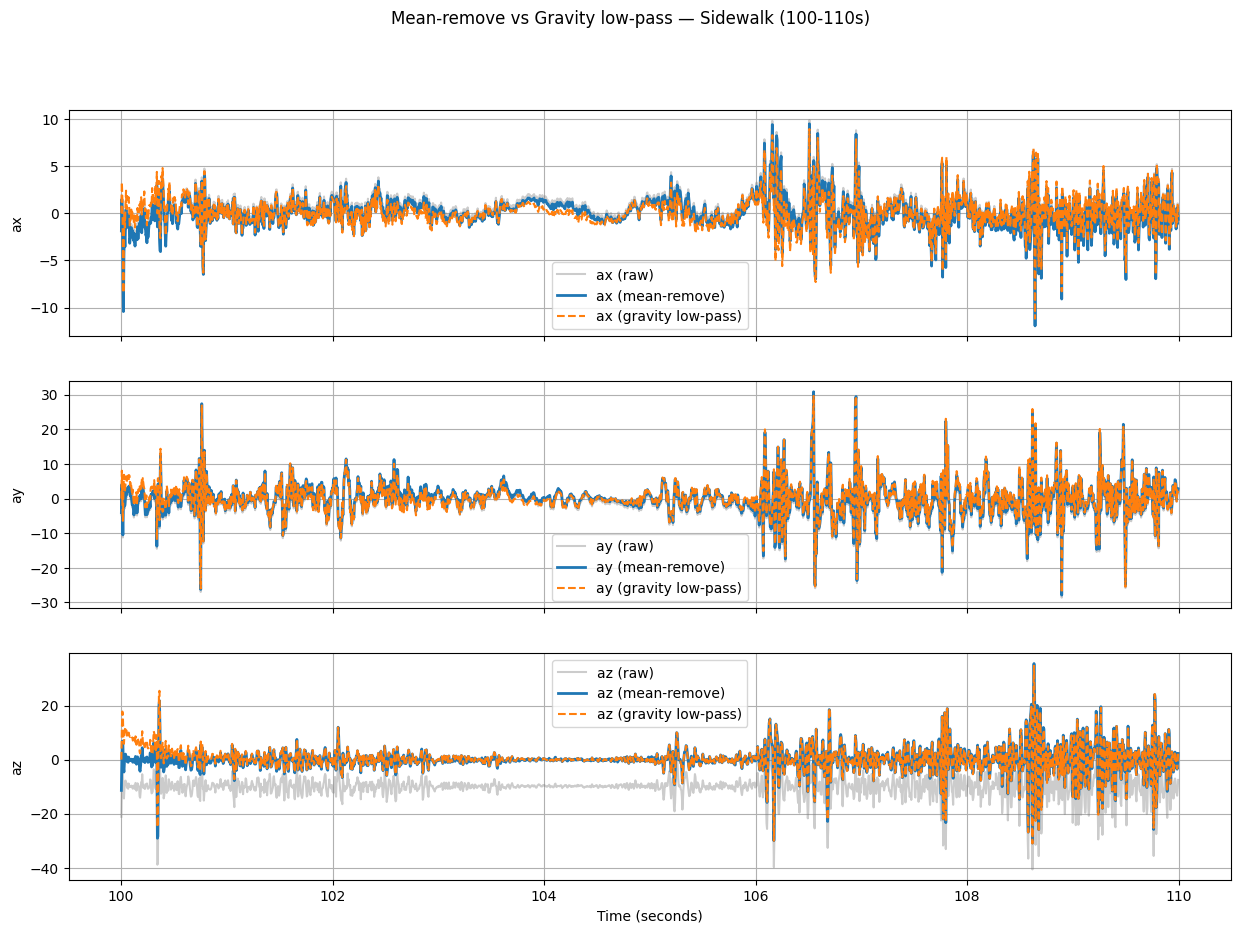

--- Sidewalk ---
ax: mean absolute difference = 0.4805
ay: mean absolute difference = 0.6225
az: mean absolute difference = 0.4967



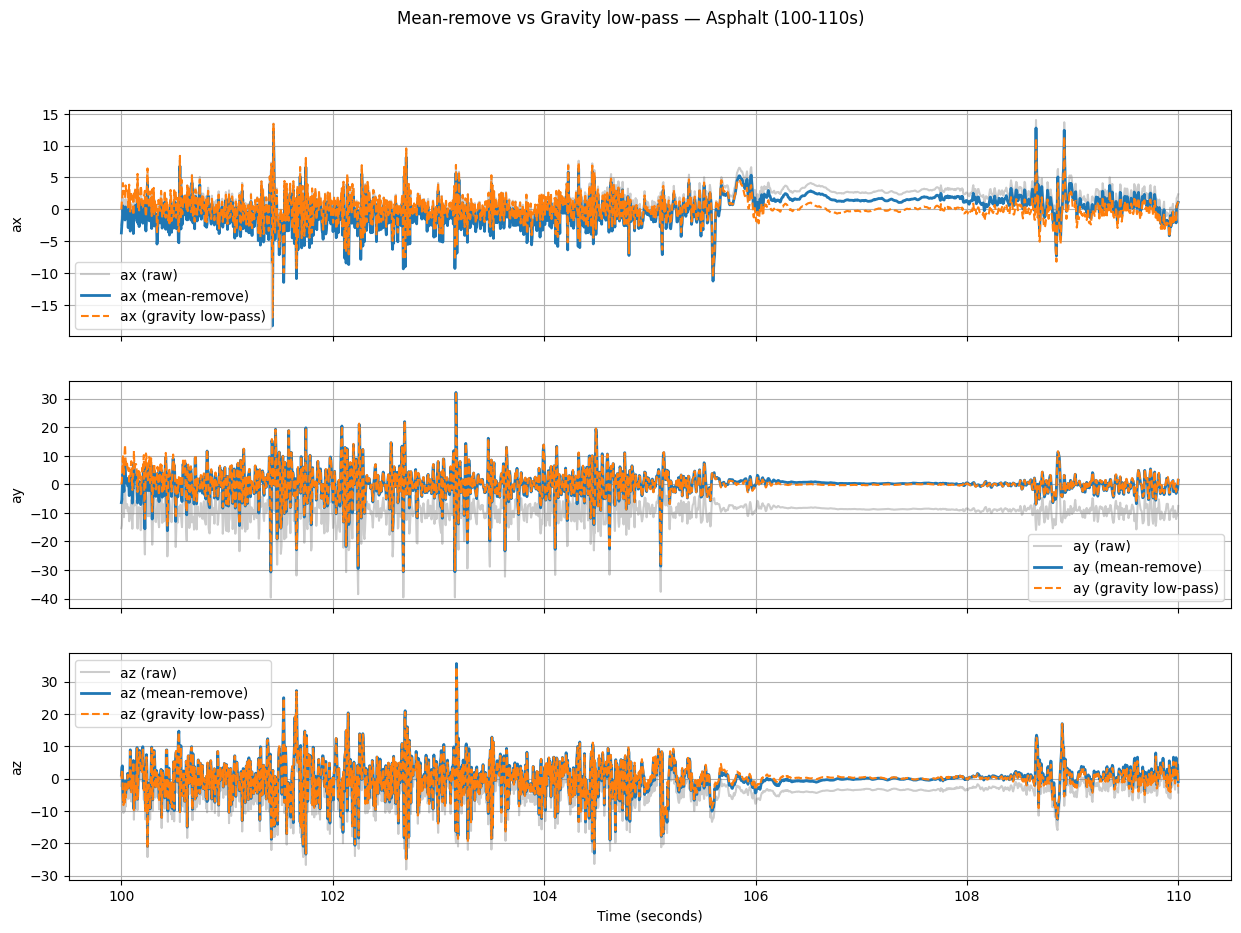

--- Asphalt ---
ax: mean absolute difference = 1.2730
ay: mean absolute difference = 0.4752
az: mean absolute difference = 0.5074



In [8]:
# 7. Compare the two gravity-removal methods on a 10-s window

for name, df in datasets.items():
    test_df = df[(df["time_sec"] >= 100) & (df["time_sec"] <= 110)].copy()
    test_df = remove_mean(test_df)
    test_df = remove_gravity_lowpass(test_df)

    fig, axes = plt.subplots(3, 1, figsize = (15, 10), sharex = True)
    for ax_plot, axis in zip(axes, ("ax", "ay", "az")):
        ax_plot.plot(test_df["time_sec"], test_df[axis], label = f"{axis} (raw)", alpha = 0.4, color = "gray")
        ax_plot.plot(test_df["time_sec"], test_df[f"{axis}_meanrm"], label = f"{axis} (mean-remove)", linewidth = 2)
        ax_plot.plot(test_df["time_sec"], test_df[f"{axis}_gravlpf"], label = f"{axis} (gravity low-pass)", linestyle = "--")
        ax_plot.set_ylabel(axis)
        ax_plot.legend()
        ax_plot.grid(True)
    axes[-1].set_xlabel("Time (seconds)")
    fig.suptitle(f"Mean-remove vs Gravity low-pass — {name} (100-110s)")
    plt.savefig(out_dir / f"gravity_removal_comparison_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

    print(f"--- {name} ---")
    for axis in ("ax", "ay", "az"):
        diff = (test_df[f"{axis}_meanrm"] - test_df[f"{axis}_gravlpf"]).abs().mean()
        print(f"{axis}: mean absolute difference = {diff:.4f}")
    print()

In [9]:
# 8. Same comparison over the full recordings
#    large differences mean the sensor orientation changed during the ride,
#    so a single mean is not a good gravity estimate

print("mean absolute difference over the FULL recording:\n")
for name, df in datasets.items():
    full_df = remove_mean(df.copy())
    full_df = remove_gravity_lowpass(full_df)
    print(f"--- {name} ---")
    for axis in ("ax", "ay", "az"):
        diff = (full_df[f"{axis}_meanrm"] - full_df[f"{axis}_gravlpf"]).abs().mean()
        print(f"{axis}: {diff:.4f}")
    print()

mean absolute difference over the FULL recording:

--- Sidewalk ---
ax: 0.5211
ay: 2.7830
az: 1.7363

--- Asphalt ---
ax: 0.7548
ay: 0.2282
az: 0.4606



In [10]:
# 9. Apply both gravity-removal methods and all three magnitudes to the full recordings

for name, df in datasets.items():
    df = remove_mean(df)
    df = remove_gravity_lowpass(df)
    df = add_candidate_methods(df, suffix = "_meanrm")
    df = add_candidate_methods(df, suffix = "_gravlpf")
    datasets[name] = df
    print(f"{name}: columns added -> {[c for c in df.columns if 'vib_' in c]}")

datasets["Sidewalk"].head()

Sidewalk: columns added -> ['vib_az_meanrm', 'vib_yz_meanrm', 'vib_xyz_meanrm', 'vib_az_gravlpf', 'vib_yz_gravlpf', 'vib_xyz_gravlpf']
Asphalt: columns added -> ['vib_az_meanrm', 'vib_yz_meanrm', 'vib_xyz_meanrm', 'vib_az_gravlpf', 'vib_yz_gravlpf', 'vib_xyz_gravlpf']


,timestamp_ns,time_sec,ax,ay,az,ax_meanrm,ay_meanrm,az_meanrm,ax_gravlpf,ay_gravlpf,az_gravlpf,vib_az_meanrm,vib_yz_meanrm,vib_xyz_meanrm,vib_az_gravlpf,vib_yz_gravlpf,vib_xyz_gravlpf
0,1781986317104198040,0.004455,-3.259163,-7.669312,-5.064337,-3.152361,-1.084197,0.675731,0.000000,0.000000,0.000000,0.675731,1.277535,3.401393,0.000000,0.000000,0.000000
1,1781986317109059143,0.009316,-3.426140,-7.766805,-4.899684,-3.319337,-1.181690,0.840385,-0.164404,-0.095991,0.162116,0.840385,1.450047,3.622242,0.162116,0.188404,0.250049
2,1781986317114075037,0.014332,-3.170181,-7.679608,-5.079830,-3.063379,-1.094494,0.660238,0.090144,-0.008659,-0.017752,0.660238,1.278214,3.319355,0.017752,0.019751,0.092283
3,1781986317118846010,0.019103,-3.249598,-7.669084,-4.975357,-3.142796,-1.083969,0.764711,0.010562,0.001837,0.085385,0.764711,1.326564,3.411296,0.085385,0.085404,0.086055
4,1781986317124320586,0.024578,-3.319280,-7.648729,-4.870912,-3.212478,-1.063615,0.869157,-0.058209,0.021849,0.186905,0.869157,1.373576,3.493812,0.186905,0.188178,0.196975


smoothed columns: ['vib_az_meanrm_smooth', 'vib_yz_meanrm_smooth', 'vib_xyz_meanrm_smooth', 'vib_az_gravlpf_smooth', 'vib_yz_gravlpf_smooth', 'vib_xyz_gravlpf_smooth']


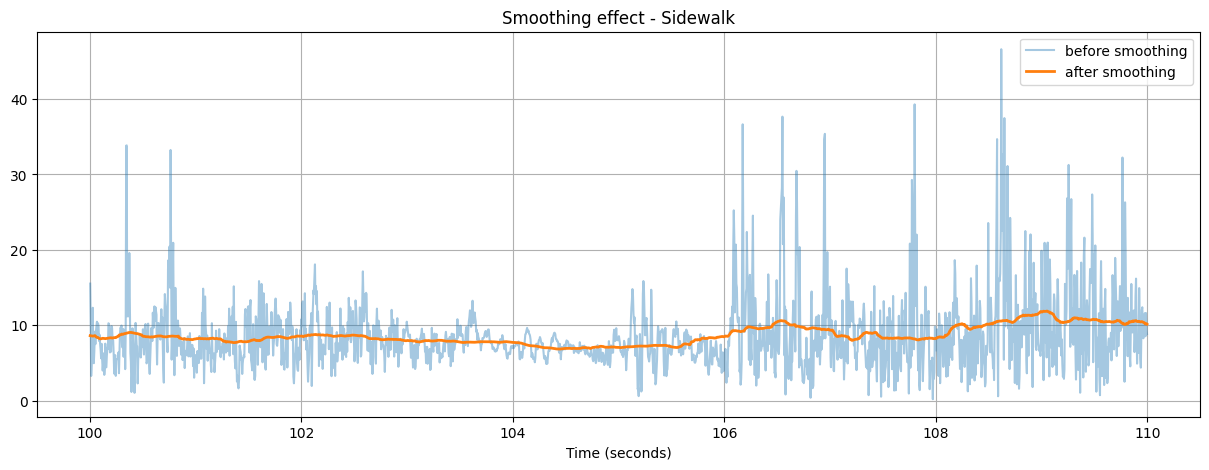

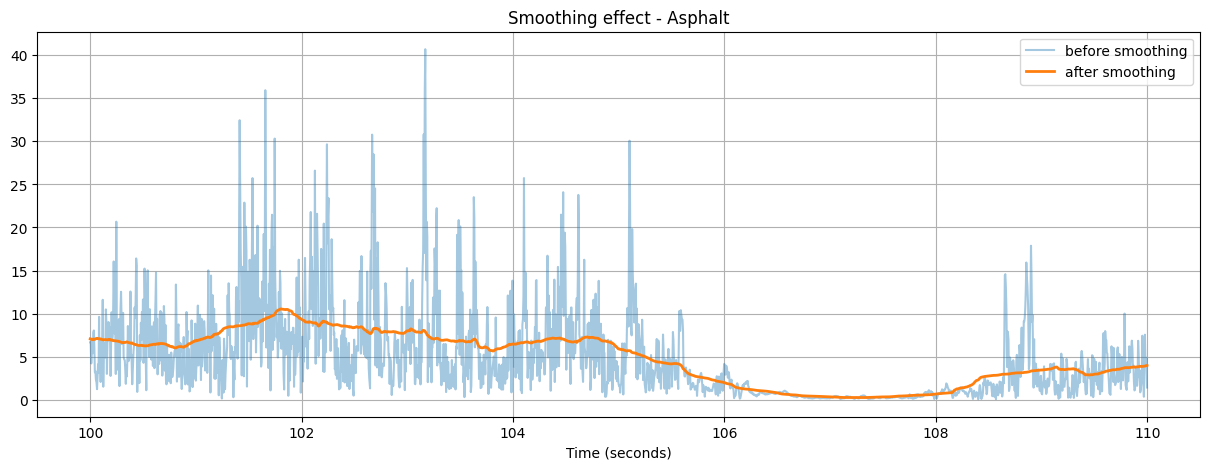

In [11]:
# 10. Smooth every candidate with a 1-s moving average (200 samples)

window_size = 200
zoom_start, zoom_end = 100, 110

for name, df in datasets.items():
    for col in [c for c in df.columns if c.startswith("vib_")]:
        df[f"{col}_smooth"] = df[col].rolling(window = window_size, center = True, min_periods = 1).mean()

print("smoothed columns:", [c for c in datasets["Sidewalk"].columns if c.endswith("_smooth")])

for name, df in datasets.items():
    zoom = df[(df["time_sec"] >= zoom_start) & (df["time_sec"] <= zoom_end)]
    plt.figure(figsize = (15, 5))
    plt.plot(zoom["time_sec"], zoom["vib_yz_meanrm"], label = "before smoothing", alpha = 0.4)
    plt.plot(zoom["time_sec"], zoom["vib_yz_meanrm_smooth"], label = "after smoothing", linewidth = 2)
    plt.title(f"Smoothing effect - {name}")
    plt.xlabel("Time (seconds)")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / f"smoothing_effect_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

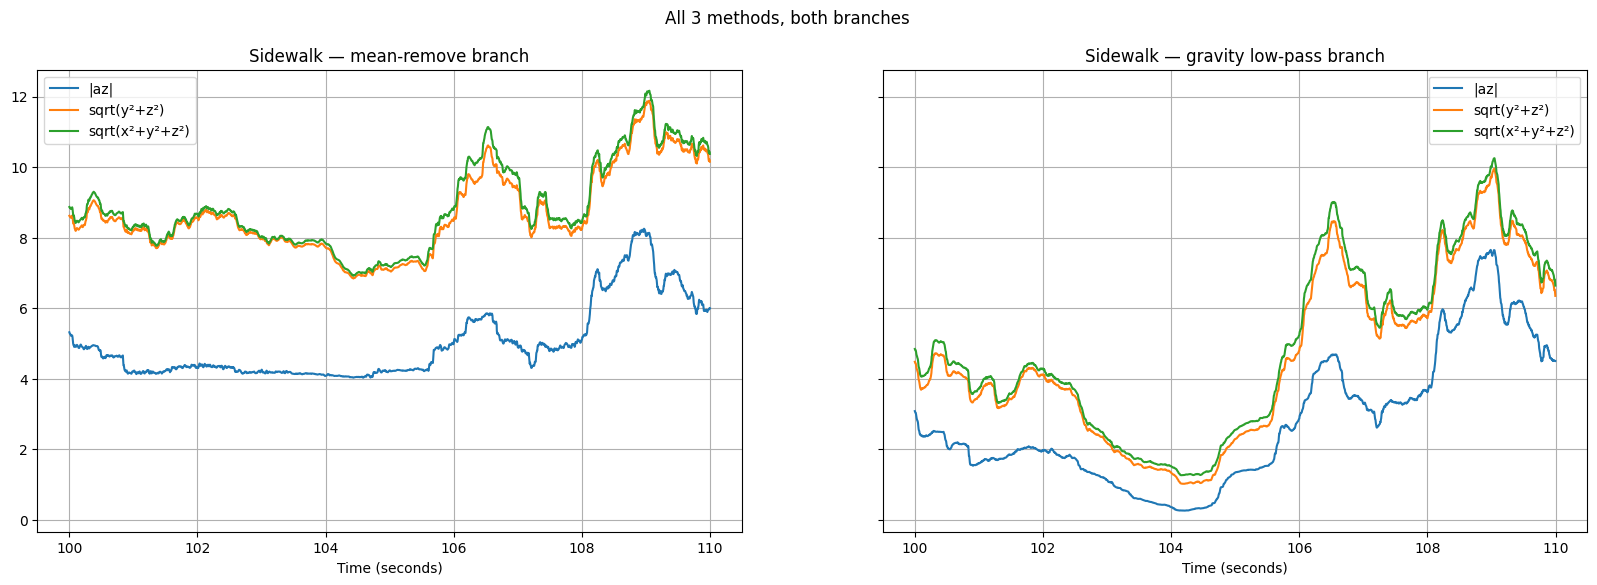

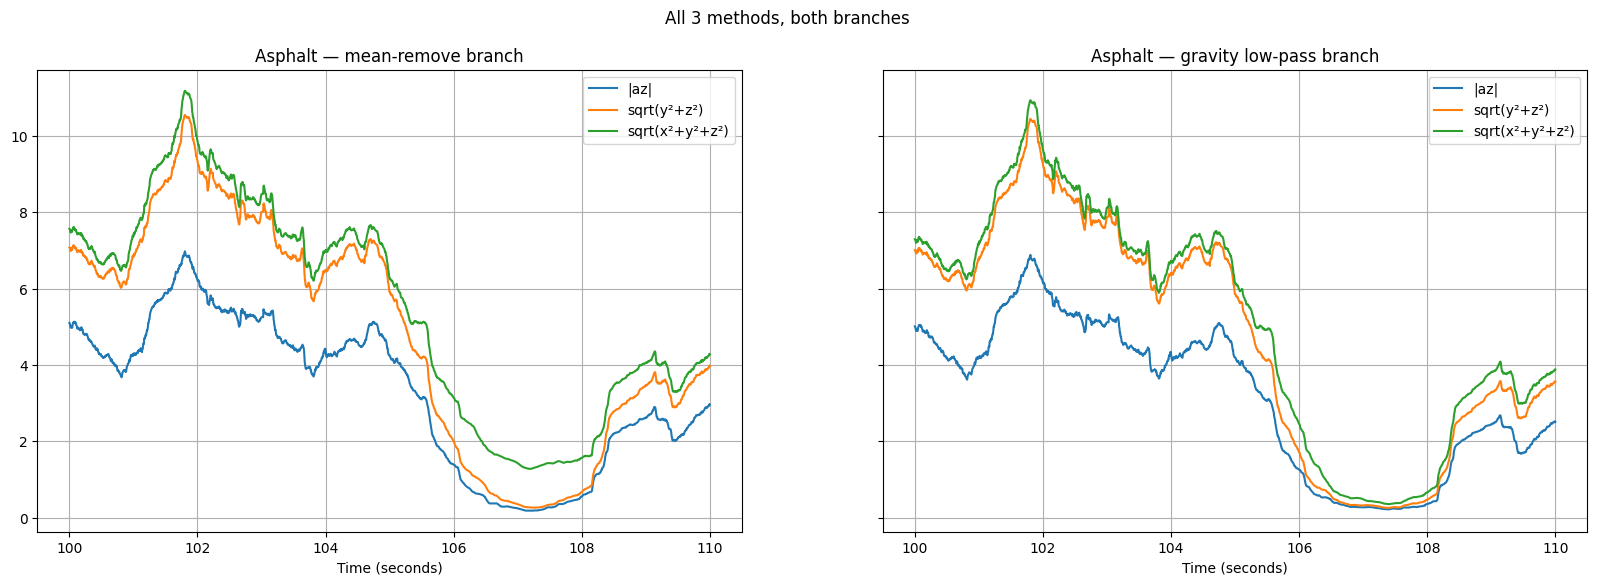

In [12]:
# 11. All three magnitudes side by side, for both gravity-removal methods

for name, df in datasets.items():
    zoom = df[(df["time_sec"] >= 100) & (df["time_sec"] <= 110)]

    fig, axes = plt.subplots(1, 2, figsize = (20, 6), sharey = True)

    axes[0].plot(zoom["time_sec"], zoom["vib_az_meanrm_smooth"], label = "|az|")
    axes[0].plot(zoom["time_sec"], zoom["vib_yz_meanrm_smooth"], label = "sqrt(y²+z²)")
    axes[0].plot(zoom["time_sec"], zoom["vib_xyz_meanrm_smooth"], label = "sqrt(x²+y²+z²)")
    axes[0].set_title(f"{name} — mean-remove branch")
    axes[0].set_xlabel("Time (seconds)")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(zoom["time_sec"], zoom["vib_az_gravlpf_smooth"], label = "|az|")
    axes[1].plot(zoom["time_sec"], zoom["vib_yz_gravlpf_smooth"], label = "sqrt(y²+z²)")
    axes[1].plot(zoom["time_sec"], zoom["vib_xyz_gravlpf_smooth"], label = "sqrt(x²+y²+z²)")
    axes[1].set_title(f"{name} — gravity low-pass branch")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle("All 3 methods, both branches")
    plt.savefig(out_dir / f"magnitude_methods_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

global min = 0.1137, global max = 27.2993
Sidewalk: normalized range = [0.044, 0.946]
Asphalt: normalized range = [0.000, 1.000]


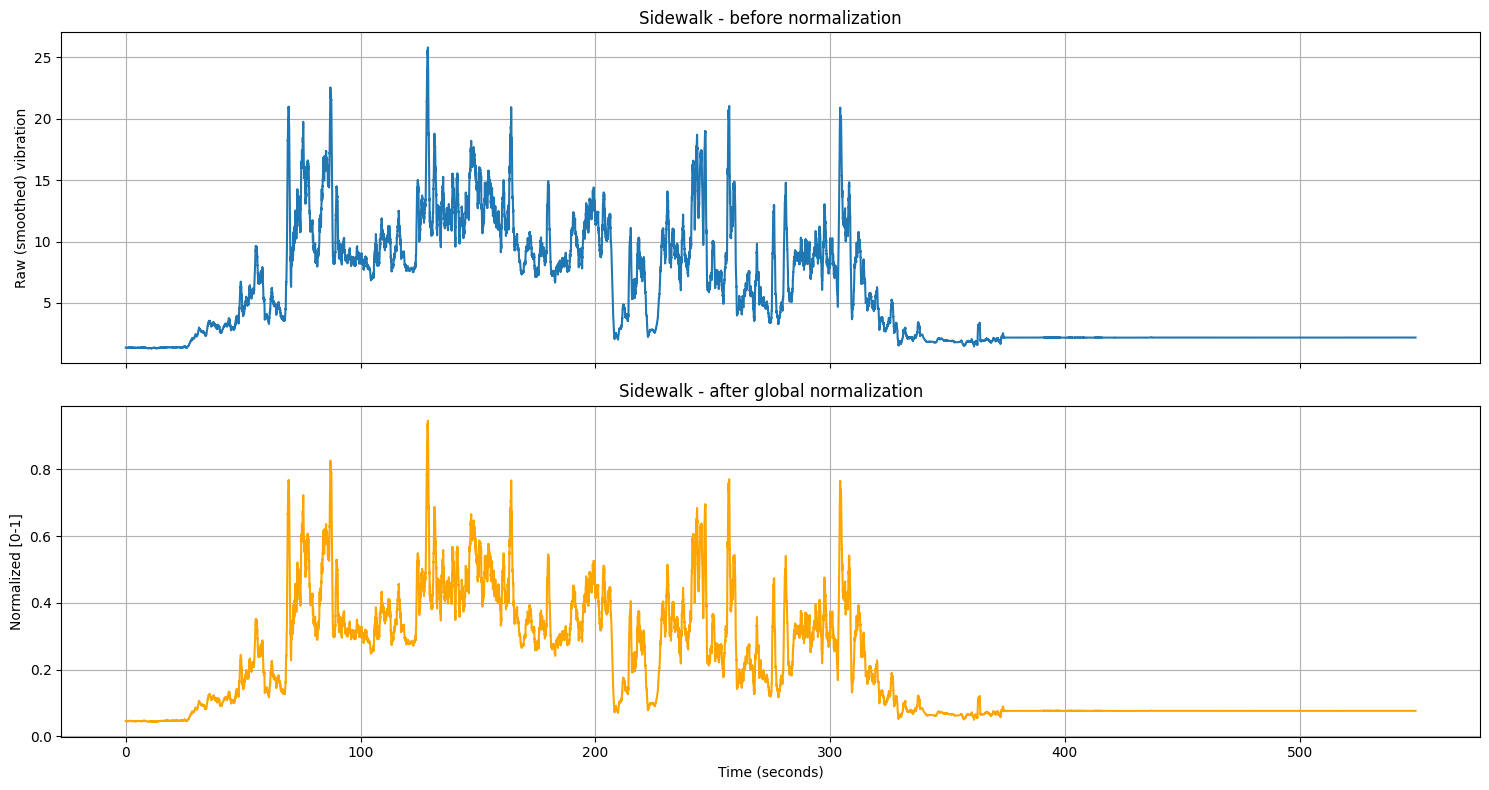

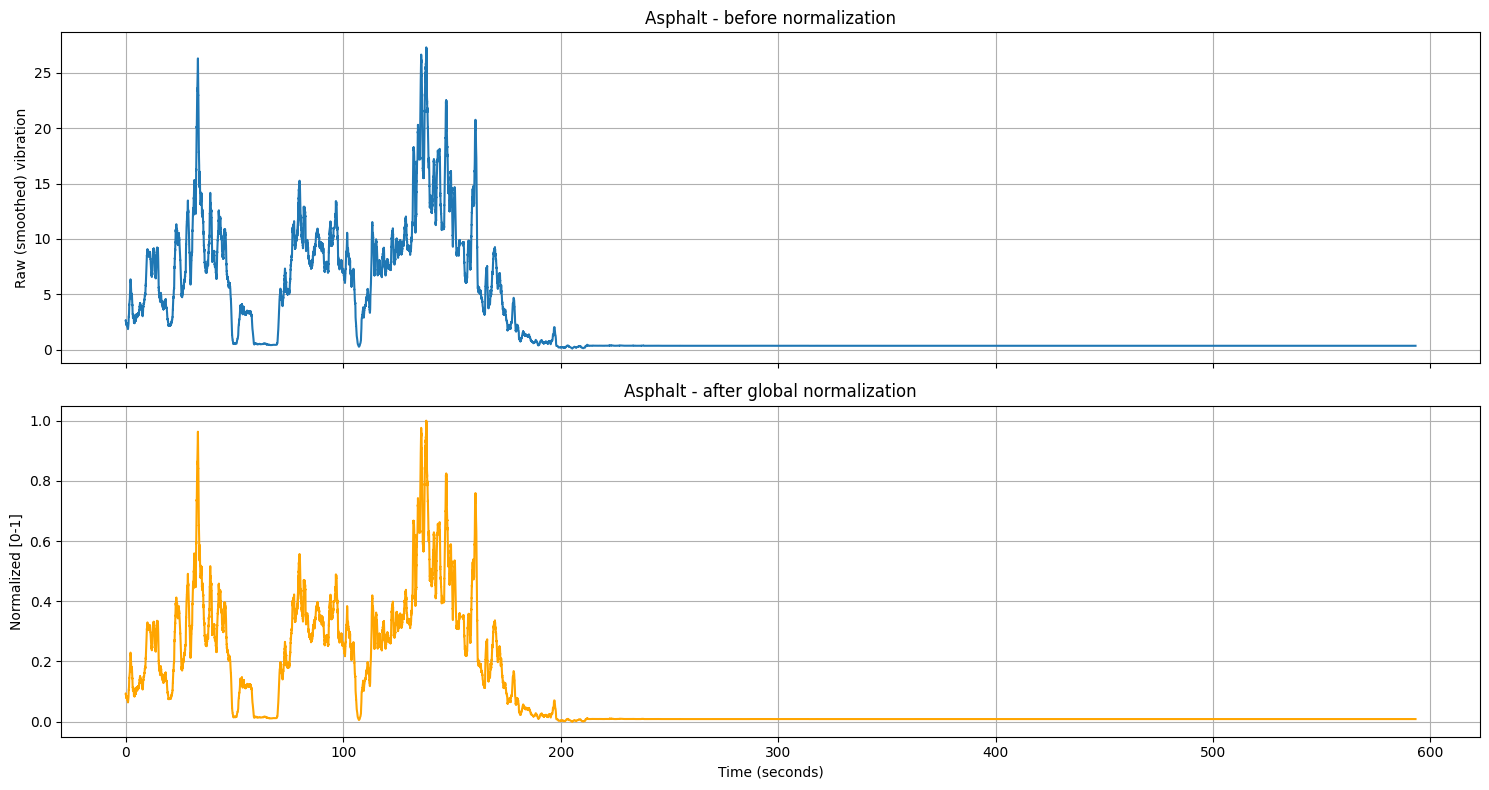

In [13]:
# 12. Normalize the chosen candidate to [0, 1] with one global min/max for both recordings,
#     so the intensity difference between surfaces is kept

chosen_col = "vib_yz_meanrm_smooth"

all_values = pd.concat([df[chosen_col] for df in datasets.values()])
global_min, global_max = all_values.min(), all_values.max()
print(f"global min = {global_min:.4f}, global max = {global_max:.4f}")

for name, df in datasets.items():
    df["vibration_norm"] = (df[chosen_col] - global_min) / (global_max - global_min)
    print(f"{name}: normalized range = [{df['vibration_norm'].min():.3f}, {df['vibration_norm'].max():.3f}]")

for name, df in datasets.items():
    fig, axes = plt.subplots(2, 1, figsize = (15, 8), sharex = True)

    axes[0].plot(df["time_sec"], df[chosen_col])
    axes[0].set_ylabel("Raw (smoothed) vibration")
    axes[0].set_title(f"{name} - before normalization")
    axes[0].grid(True)

    axes[1].plot(df["time_sec"], df["vibration_norm"], color = "orange")
    axes[1].set_ylabel("Normalized [0-1]")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_title(f"{name} - after global normalization")
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(out_dir / f"normalization_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

In [14]:
# 13. Smooth threshold (smoothstep): values below threshold_low go to zero,
#     values above threshold_high are kept, smooth ramp in between

threshold_low = 0.15
threshold_high = 0.3

def smooth_threshold(values, low, high):
    result = np.clip((values - low) / (high - low), 0, 1)
    result = result * result * (3 - 2 * result)
    return values * result

for name, df in datasets.items():
    df["vibration_threshold"] = smooth_threshold(
        df["vibration_norm"].to_numpy(), threshold_low, threshold_high
    )
    pct_near_zero = (df["vibration_threshold"] < 0.01).mean() * 100
    print(f"{name}: {pct_near_zero:.1f}% samples near-zero (<0.01)")

Sidewalk: 55.8% samples near-zero (<0.01)
Asphalt: 79.1% samples near-zero (<0.01)


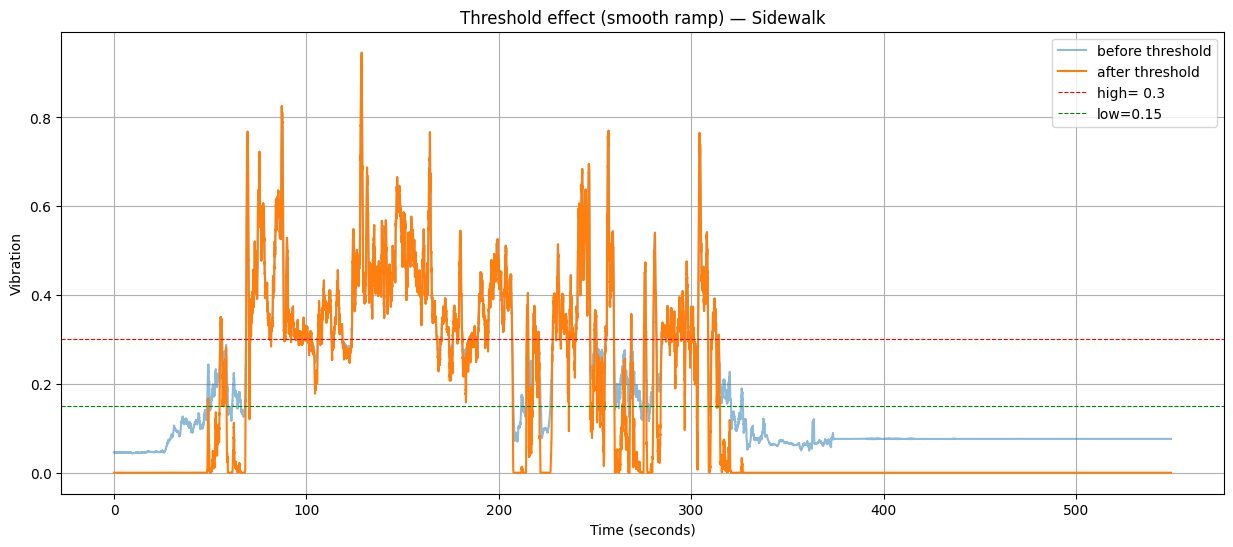

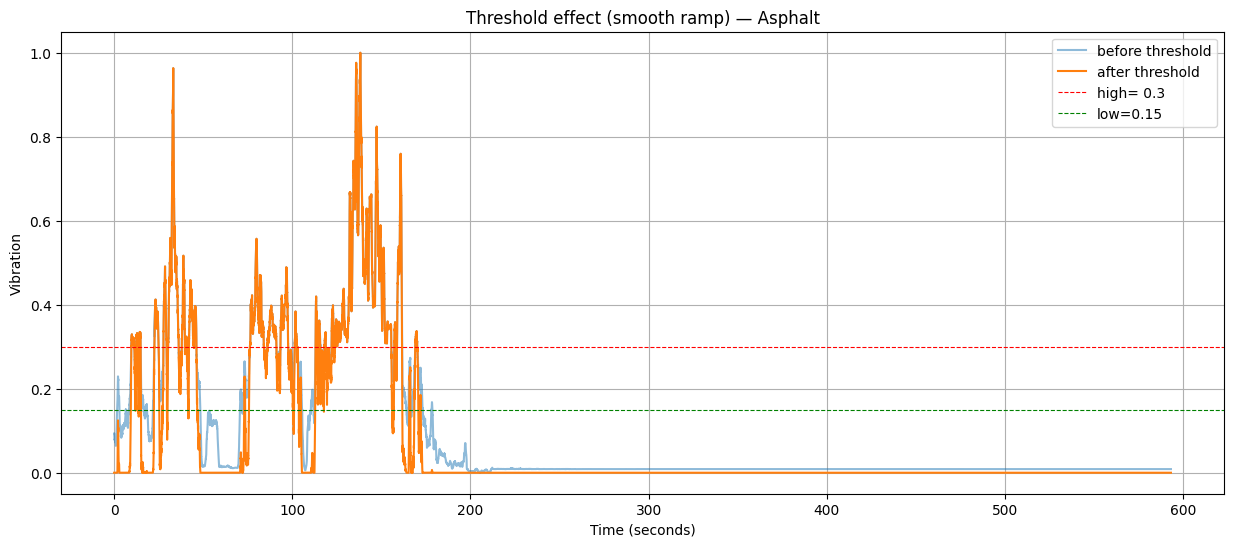

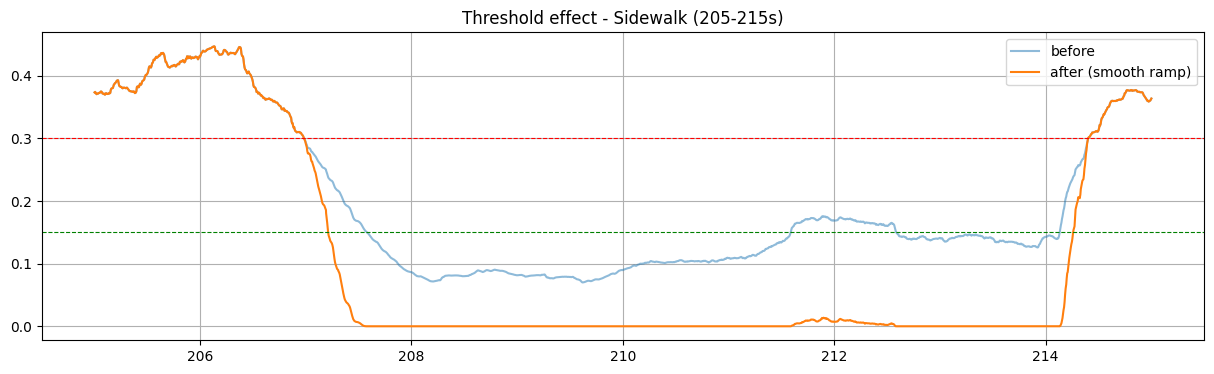

In [15]:
# 14. Threshold effect: full recordings and a 10-s zoom

for name, df in datasets.items():
    plt.figure(figsize = (15, 6))
    plt.plot(df["time_sec"], df["vibration_norm"], label = "before threshold", alpha = 0.5)
    plt.plot(df["time_sec"], df["vibration_threshold"], label = "after threshold", linewidth = 1.5)
    plt.axhline(threshold_high, color = "red", linestyle = "--", linewidth = 0.8, label = f"high= {threshold_high}")
    plt.axhline(threshold_low, color = "green", linestyle = "--", linewidth = 0.8, label = f"low={threshold_low}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Vibration")
    plt.title(f"Threshold effect (smooth ramp) — {name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / f"threshold_effect_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

zoom = datasets["Sidewalk"]
zoom = zoom[(zoom["time_sec"] >= 205) & (zoom["time_sec"] <= 215)]
plt.figure(figsize = (15, 4))
plt.plot(zoom["time_sec"], zoom["vibration_norm"], label = "before", alpha = 0.5)
plt.plot(zoom["time_sec"], zoom["vibration_threshold"], label = "after (smooth ramp)", linewidth = 1.5)
plt.axhline(threshold_high, color = "red", linestyle = "--", linewidth = 0.8)
plt.axhline(threshold_low, color = "green", linestyle = "--", linewidth = 0.8)
plt.legend()
plt.grid(True)
plt.title("Threshold effect - Sidewalk (205-215s)")
plt.savefig(out_dir / "threshold_effect_zoom_Sidewalk.png", dpi = 200, bbox_inches = "tight")
plt.show()

Sidewalk: saved 110881 rows -> /Users/sarvin/Desktop/scooter_pro/escooter-dataset-exploration/results/unity_vibration_output_Sidewalk.csv
Asphalt: saved 119128 rows -> /Users/sarvin/Desktop/scooter_pro/escooter-dataset-exploration/results/unity_vibration_output_Asphalt.csv


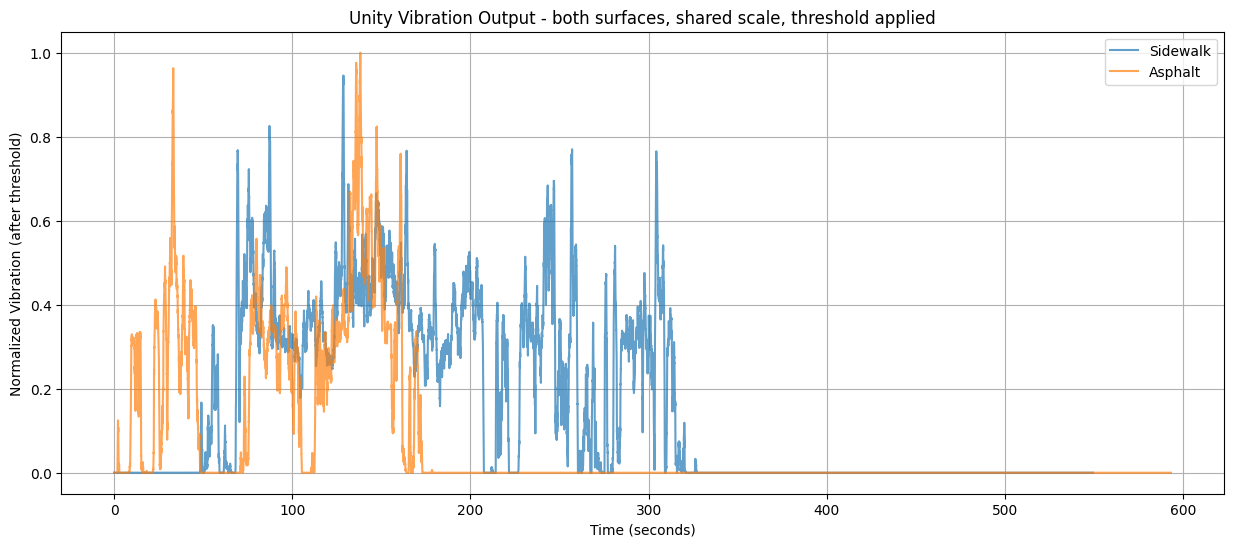

In [16]:
# 15. Save the vibration signal for Unity and plot both surfaces on the shared scale

for name, df in datasets.items():
    output = df[["time_sec", "vibration_norm", "vibration_threshold"]].copy()
    output.to_csv(out_dir / f"unity_vibration_output_{name}.csv", index = False)
    print(f"{name}: saved {len(output)} rows -> {out_dir / f'unity_vibration_output_{name}.csv'}")

plt.figure(figsize = (15, 6))
for name, df in datasets.items():
    plt.plot(df["time_sec"], df["vibration_threshold"], label = name, alpha = 0.7)
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Vibration (after threshold)")
plt.title("Unity Vibration Output - both surfaces, shared scale, threshold applied")
plt.legend()
plt.grid(True)
plt.savefig(out_dir / "unity_vibration_output_both.png", dpi = 300, bbox_inches = "tight")
plt.show()